# Unsupervised & Supervised Digit Recognition

#### E/21/087 -  Dewagedara D.M.E.S.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the dataset
data = pd.read_csv("Digits_Lab_01.csv").to_numpy()

### Task 1 - Reconstruct and Visualize Digits 

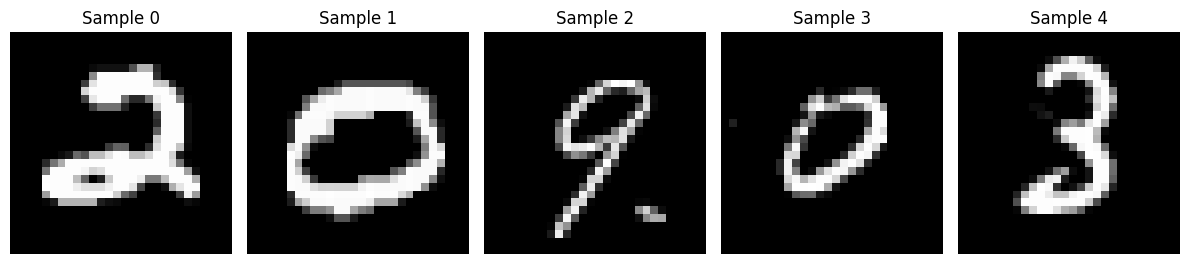

In [8]:
# Set up a figure to display a small set of samples
plt.figure(figsize=(12, 4))

for i in range(5):
    # Reshape the i-th row from (784,) to (28, 28)
    digit_image = data[i].reshape(28, 28)
    
    # Create a subplot for each digit
    plt.subplot(1, 5, i + 1)
    plt.imshow(digit_image, cmap="gray")
    plt.title(f"Sample {i}")
    plt.axis('off') 

plt.tight_layout()
plt.show()

### Answer -

#### 1. How numeric vectors become recognizable digits

Each handwritten digit in the dataset is stored as a numeric vector, where every value represents the intensity of a single pixel. Initially, this vector is one-dimensional, so it does not visually resemble a digit. When the vector is reshaped into a 28 × 28 grid, the pixel values are placed back into their original spatial positions. Adjacent pixel intensities combine to form visible patterns such as curves, edges, and strokes. When these values are displayed using a grayscale color map, darker pixels represent inked regions and lighter pixels represent the background. As a result, the arrangement of pixel intensities forms shapes that the human eye can recognize as handwritten digits.


#### 2. Why correct reshaping (row → 2D grid) is essential

Correct reshaping is essential because images rely on the spatial relationship between pixels. Each pixel has a specific position relative to others (row and column). If the numeric vector is reshaped incorrectly, pixel positions are scrambled, breaking these spatial relationships. This leads to distorted or meaningless images that do not resemble digits. Proper reshaping ensures that each pixel is placed in its correct location, preserving the structure of the digit. This is crucial not only for visualization but also for machine learning models, which depend on consistent spatial patterns to learn and recognize digits accurately.

### Task 2 — Cluster Digits with K-Means

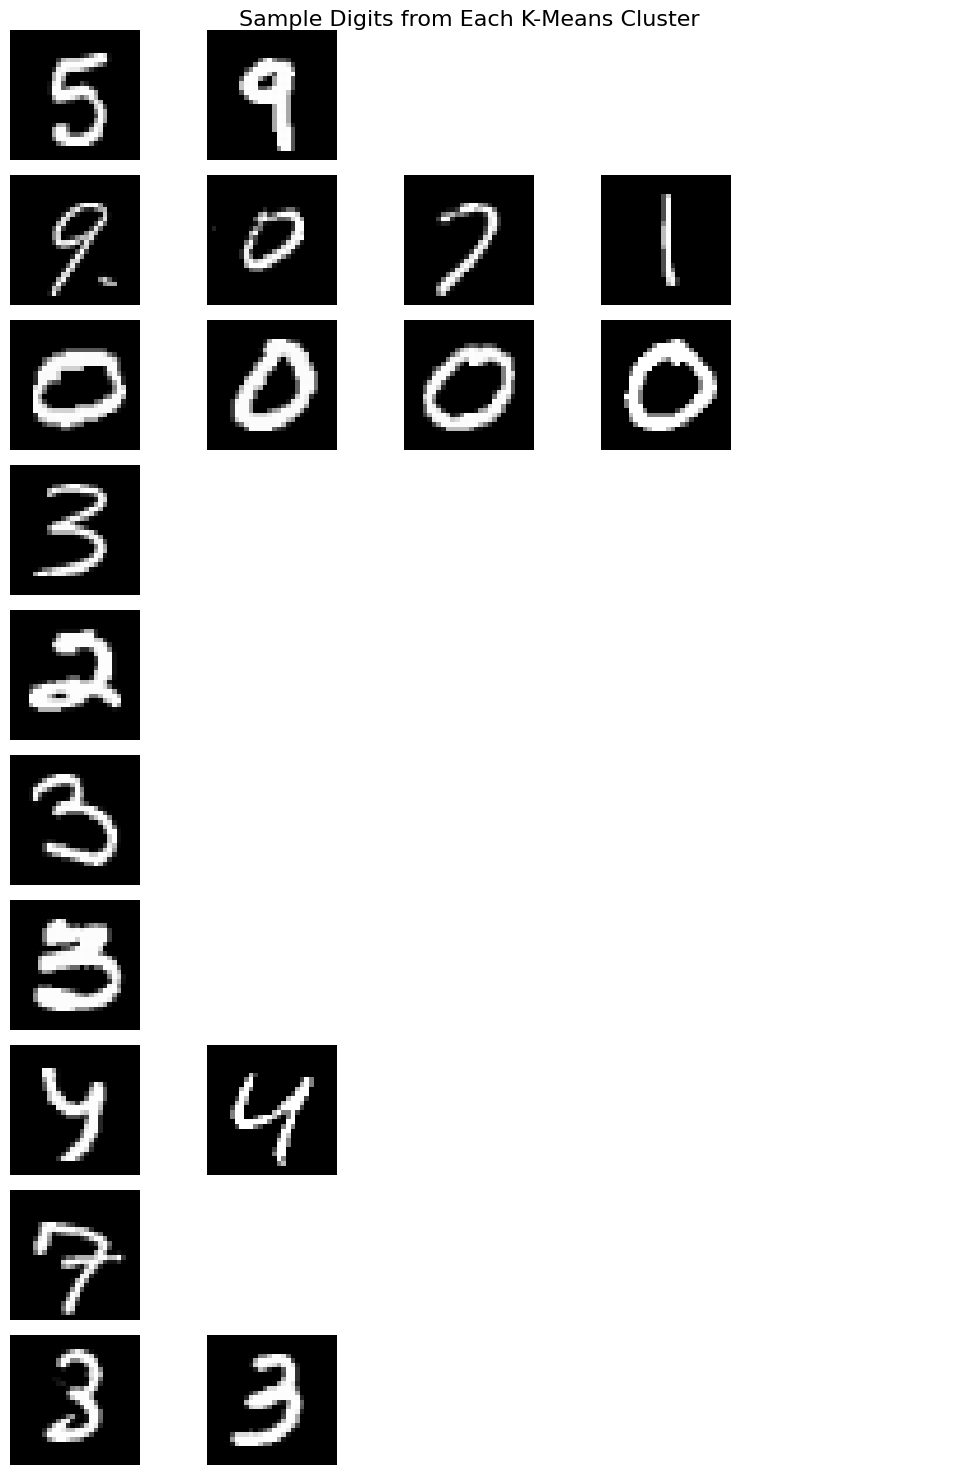

In [4]:
# Apply K-Means clustering
k = 10 
kmeans = KMeans(n_clusters=k, n_init="auto", random_state=0)
labels = kmeans.fit_predict(data)

# Visualize sample digits per cluster
rows, cols = 10, 5 
fig, axes = plt.subplots(rows, cols, figsize=(10, 15))
fig.suptitle("Sample Digits from Each K-Means Cluster", fontsize=16)

for cluster in range(k):
    cluster_indices = np.where(labels == cluster)[0]  
    num_samples = min(cols, len(cluster_indices))   
    
    for i in range(num_samples):
        idx = cluster_indices[i]
        digit = data[idx].reshape(28, 28)
        axes[cluster, i].imshow(digit, cmap="gray")
        axes[cluster, i].axis("off")

    for i in range(num_samples, cols):
        axes[cluster, i].axis("off")
    
    axes[cluster, 0].set_ylabel(f"Cluster {cluster}", fontsize=12)

plt.tight_layout()
plt.show()

### Answer -

#### 1. Which digits cluster clearly?
In output, **Cluster 3 (zeros)** is the most distinct and successful.
  - **Observations:** Every sample in the third row shows a clear **"0"**.
  - **Reasoning:** Digits like **"0"** have a very consistent "ink footprint." Because most people draw a circle in roughly the same area of the $28 \times 28$ grid, the Euclidean distance between these vectors is small, allowing the algorithm to group them with high purity.


#### 2. Which clusters mix classes?
Cluster 2 (second row) is a prime example of a "mixed" cluster.
 - **Observations:** This cluster contains a 9, 0, 7, and 1.
 - **Reasoning:** This occurs because these specific instances likely share a similar "thinness" or spatial orientation. For example, the "7" and "1" both consist of thin vertical/slanted lines in the center of the frame. To K-Means, the coordinate overlap of these thin lines makes them mathematically "closer" to each other than to a thick "7" or a thick "1" in another cluster.

#### 3. Why clustering relies only on pixel space, not labels
K-Means is an unsupervised algorithm, meaning it is "blind" to the actual identity of the numbers.

 - **Mathematical Similarity:** The model views each image as a point in 784-dimensional space. It only understands Euclidean distance—how much the white pixels of one image overlap with another.
 - **Lack of Semantics:** It does not understand the concept of a "loop" or a "crossbar" as a human does. It only sees pixel intensities.
 - **Style vs. Meaning:** If a "5" (Cluster 1, first image) is written with a specific slant, it may be mathematically more similar to a "9" (Cluster 1, second image) than to a "5" written upright. Because there are no labels to "correct" the model, it groups these based on raw visual overlap rather than the intended numerical value.

### Task 3 — Train a Simple MLP Classifier

Test Accuracy: 95.70%


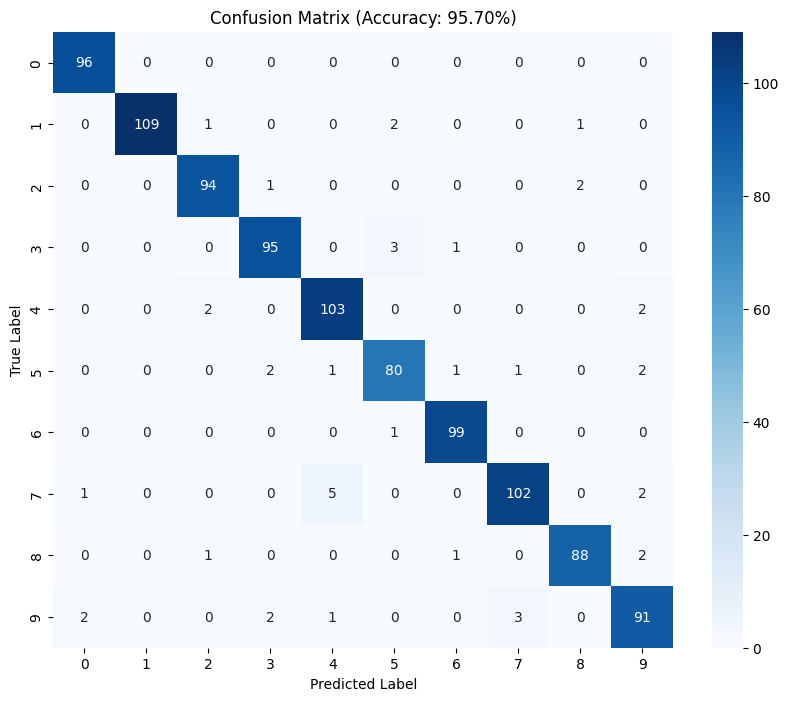

In [12]:
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()
y = mnist.target.to_numpy().astype(int)

# Use only first 5000 samples
X = X[:5000]
y = y[:5000]

# Normalize
X = X / 255.0

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=1)
mlp.fit(X_train, y_train)

# Predict
y_pred = mlp.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Accuracy: {accuracy*100:.2f}%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Answer -

#### 1. Why treating pixels as independent features ignores spatial structure:
In an MLP, the input is a one-dimensional vector of 784 pixel values. The model treats each pixel as an independent feature and does not explicitly encode spatial relationships such as vertical or horizontal adjacency. It has no inherent understanding that neighboring pixels in the vector correspond to neighboring positions in a 2D image. If the same consistent pixel permutation were applied to all images, the MLP would still be able to learn, because it does not rely on 2D geometry but only on learned feature weights.

#### 2. Why it can still learn coarse patterns:
Even without explicit spatial knowledge, the MLP can learn global statistical correlations between pixel intensities and class labels. During training, hidden layer neurons act as weighted filters that respond to specific combinations of active pixels. For example, a neuron may activate when certain pixels corresponding to the bottom loop of an "8" or the top horizontal bar of a "7" have high intensity. Although the network does not explicitly detect edges or shapes, it learns patterns based on the probability that particular groups of pixels are simultaneously active for specific digits. This allows the MLP to capture coarse structural patterns and achieve good classification accuracy.

### Task 4 — Train a CNN and Compare

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import numpy as np

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor()   # converts to [1, 28, 28] and scales to [0,1]
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(self.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop (3 epochs for demo)
for epoch in range(3):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

# Evaluate
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"CNN Test Accuracy: {accuracy * 100:.2f}%")


100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:18<00:00, 527kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 86.5kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 569kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.57MB/s]


Epoch 1, Loss: 197.7440
Epoch 2, Loss: 53.7769
Epoch 3, Loss: 38.4741
CNN Test Accuracy: 98.81%


### Answer -

#### 1. How Convolutions Exploit Local Neighborhoods

Unlike a Multilayer Perceptron (MLP), where each pixel is treated as an independent feature, a Convolutional Neural Network (CNN) uses filters (kernels) to analyze small regions of the image.

**Local Connectivity**

Each convolutional filter examines only a small spatial region (e.g., 3×3 pixels) at a time.
This enables the network to detect local patterns such as edges, curves, and corners.
Since nearby pixels are usually related in images, focusing on local neighborhoods helps the network capture meaningful visual structures.

**Spatial Hierarchy**

CNNs learn features hierarchically:

  - Early layers detect simple patterns (edges, lines).
  - Deeper layers combine these patterns to form more complex structures (e.g., the loop of a “6” or the crossbar of a “4”).

This hierarchical feature learning makes CNNs especially powerful for image recognition.

**Weight Sharing and Translation Invariance**

The same filter is applied (slid) across the entire image.
This process is called weight sharing.
As a result:
    - If a feature (e.g., a loop) is learned in one region,
    - The network can detect the same feature anywhere else in the image.

This property is known as translation invariance.

#### 2. Why CNNs Outperform MLPs on Images

**Preservation of Spatial Structure**

CNNs preserve the original 28×28 grid structure of the image.
This means the network understands which pixels are neighbors.

In contrast, an MLP flattens the image into a 784-dimensional vector, losing spatial relationships between pixels.

**Parameter Efficiency**

Because CNN filters are small and shared across the image, CNNs typically require fewer parameters than a fully connected MLP of similar depth.
This makes CNNs:
 - Easier to train
 - Less prone to overfitting
 - More efficient for high-dimensional image data

**Robustness to Variations**

Pooling layers (e.g., MaxPooling) reduce spatial resolution while preserving important features.
This makes CNNs more robust to small variations such as:
 - Slight shifts
 - Thickness differences
 - Minor distortions

As a result, CNNs generally achieve higher accuracy on image classification tasks compared to MLPs.

### Task 5 — Analyze Misclassifications 

#### 1. When Unsupervised Clustering Fails

- **The Issue:** K-Means struggles when different digits share a similar "ink footprint" or a single digit is written in multiple styles.

- **Ambiguity:** A "7" with a crossbar vs. without may be placed in separate clusters.

- **Blob Problem:** Closed shapes, like a "4" with a top loop, can resemble a "9" in pixel density.

- **Key Weakness:** Clustering cannot learn that visually different shapes can represent the same digit.

#### 2. When MLP Struggles

- **The Issue:** MLPs are sensitive to shifts, rotations, or resizing.

- **Lack of Invariance:** Pixels are treated independently, so moving a "1" slightly triggers entirely different features.

- **Noise Sensitivity:** Random stray pixels can mislead the network.

- **Key Weakness:** Ignores 2D spatial structure, making it fragile to positional changes.

#### 3. How CNN Corrects These Issues

- **Spatial Feature Detection:** CNNs detect patterns like “vertical lines near a loop” rather than individual pixels.

- **Pooling:** Max pooling provides robustness to shifts, slants, or thickness variations.

- **Hierarchical Learning:** CNNs capture overall structure — a “0” is recognized as a continuous circular edge.

### Final Reflection

**Benefit — Discovering Natural Data Structures:**
Clustering before classification helps explore the data and reveal natural groupings. For digits, it can show variations within the same number (e.g., two styles of “2”), highlighting where a classifier might struggle and guiding model choice or feature engineering.

**Limitation — Lack of Semantic Alignment:**
Clustering groups by pixel similarity, not meaning. Different-looking versions of the same digit (e.g., thin vs. thick “1”) might be separated, and noise or slanted writing can create misleading clusters, which is unhelpful for accurate classification.